In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Bidirectional, Dense

In [ ]:
from re import X
vocab_size=10000
max_length=200
embedding_dim=128
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=vocab_size)
X_train=pad_sequences(X_train,maxlen=max_length)
X_test=pad_sequences(X_test,maxlen=max_length)
print("Training Shape",X_train.shape)
print("Testing Shape",X_test.shape)

Training Shape (25000, 200)
Testing Shape (25000, 200)


### ***Commom Training Function***

In [ ]:
import time
def train_model(model,X_train,y_train,X_test,y_test, model_name):
  start_time=time.time()
  model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
  history=model.fit(X_train,y_train,epochs=3,batch_size=128,validation_split=0.2,verbose=1)
  loss,accuracy=model.evaluate(X_test,y_test,verbose=0)
  training_time=time.time()-start_time
  print("\n"+"="*50)
  print(model_name)
  print("Training Time:",training_time)
  print("Accuracy:",accuracy)
  print("="*50)
  return accuracy,training_time,history

# ***Model1 - Simple RNN***

In [ ]:
simple_rnn = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    SimpleRNN(128),
    Dense(1, activation='sigmoid')
])

simple_rnn.summary()

rnn_acc, rnn_time, rnn_history = train_model(
    simple_rnn,
    X_train, y_train,
    X_test, y_test,
    'SimpleRNN'
)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.5908 - loss: 0.6519 - val_accuracy: 0.7178 - val_loss: 0.5534
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7969 - loss: 0.4392 - val_accuracy: 0.7476 - val_loss: 0.5113
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8261 - loss: 0.3908 - val_accuracy: 0.7520 - val_loss: 0.5060

SimpleRNN
Training Time: 18.370856285095215
Accuracy: 0.7581999897956848


# ***Model2-LSTM***

In [ ]:
lstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    LSTM(128),
    Dense(1, activation='sigmoid')
])

lstm_model.summary()

lstm_acc, lstm_time, lstm_history = train_model(
    lstm_model,
    X_train, y_train,
    X_test, y_test,
    'LSTM'
)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7569 - loss: 0.4799 - val_accuracy: 0.8640 - val_loss: 0.3261
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8971 - loss: 0.2657 - val_accuracy: 0.8436 - val_loss: 0.3746
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9265 - loss: 0.1947 - val_accuracy: 0.8702 - val_loss: 0.3269

LSTM
Training Time: 16.86379623413086
Accuracy: 0.8623999953269958


# ***Model3-GRU***

In [ ]:
gru_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    GRU(128),
    Dense(1, activation='sigmoid')
])

gru_model.summary()

gru_acc, gru_time, gru_history = train_model(
    gru_model,
    X_train, y_train,
    X_test, y_test,
    'GRU'
)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7295 - loss: 0.5204 - val_accuracy: 0.8396 - val_loss: 0.3625
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8701 - loss: 0.3078 - val_accuracy: 0.8416 - val_loss: 0.3527
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9214 - loss: 0.2057 - val_accuracy: 0.8694 - val_loss: 0.3513

GRU
Training Time: 14.333044052124023
Accuracy: 0.8596799969673157


# ***Model-4 BiDirectional RNN***

In [ ]:
birnn_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    Bidirectional(SimpleRNN(128)),
    Dense(1, activation='sigmoid')
])

birnn_model.summary()

birnn_acc, birnn_time, birnn_history = train_model(
    birnn_model,
    X_train, y_train,
    X_test, y_test,
    'BiRNN'
)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.5725 - loss: 0.6745 - val_accuracy: 0.6104 - val_loss: 0.6493
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6493 - loss: 0.6249 - val_accuracy: 0.6412 - val_loss: 0.6154
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.7836 - loss: 0.4650 - val_accuracy: 0.7620 - val_loss: 0.5036

BiRNN
Training Time: 30.004423141479492
Accuracy: 0.7680000066757202


# ***BiDirectional LSTM***

In [ ]:
bilstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    Bidirectional(LSTM(128)),
    Dense(1, activation='sigmoid')
])

bilstm_model.summary()

bilstm_acc, bilstm_time, bilstm_history = train_model(
    bilstm_model,
    X_train, y_train,
    X_test, y_test,
    'BiLSTM'
)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7620 - loss: 0.4879 - val_accuracy: 0.8500 - val_loss: 0.3512
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.8923 - loss: 0.2714 - val_accuracy: 0.8198 - val_loss: 0.3923
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9215 - loss: 0.2078 - val_accuracy: 0.8720 - val_loss: 0.3251

BiLSTM
Training Time: 29.71819806098938
Accuracy: 0.8645600080490112


# ***BiDirectional GRU***

In [ ]:
bigru_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    Bidirectional(GRU(128)),
    Dense(1, activation='sigmoid')
])

bigru_model.summary()

bigru_acc, bigru_time, bigru_history = train_model(
    bigru_model,
    X_train, y_train,
    X_test, y_test,
    'BiGRU'
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.7587 - loss: 0.4792 - val_accuracy: 0.8434 - val_loss: 0.3615
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8941 - loss: 0.2649 - val_accuracy: 0.7960 - val_loss: 0.4569
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9181 - loss: 0.2083 - val_accuracy: 0.8630 - val_loss: 0.3490

BiGRU
Training Time: 24.992767810821533
Accuracy: 0.8435199856758118


# ***Comparision Table***

In [ ]:
comparison_df = pd.DataFrame({
    'Model': [
        'SimpleRNN',
        'LSTM',
        'GRU',
        'BiRNN',
        'BiLSTM',
        'BiGRU'
    ],
    'Accuracy': [
        rnn_acc,
        lstm_acc,
        gru_acc,
        birnn_acc,
        bilstm_acc,
        bigru_acc
    ],
    'Training Time (sec)': [
        rnn_time,
        lstm_time,
        gru_time,
        birnn_time,
        bilstm_time,
        bigru_time
    ]
})

comparison_df = comparison_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(comparison_df)

       Model  Accuracy  Training Time (sec)
4     BiLSTM   0.86456            29.718198
1       LSTM   0.86240            16.863796
2        GRU   0.85968            14.333044
5      BiGRU   0.84352            24.992768
3      BiRNN   0.76800            30.004423
0  SimpleRNN   0.75820            18.370856


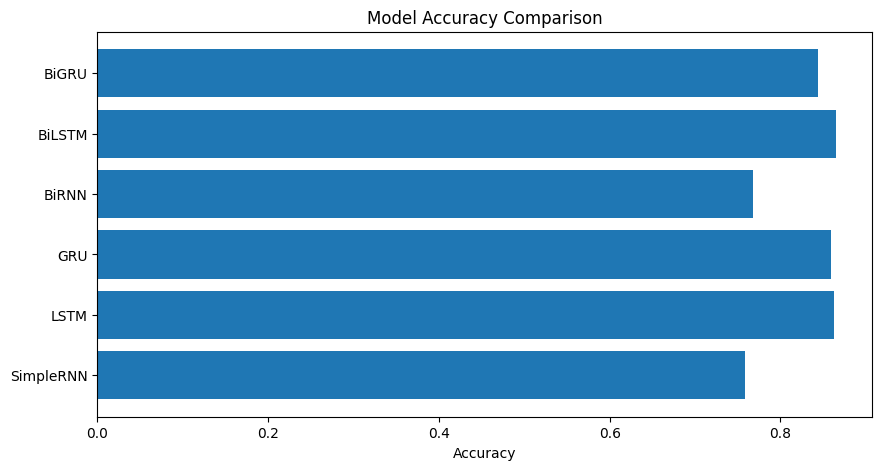

In [ ]:
plt.figure(figsize=(10,5))
plt.barh(models, accuracies)
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

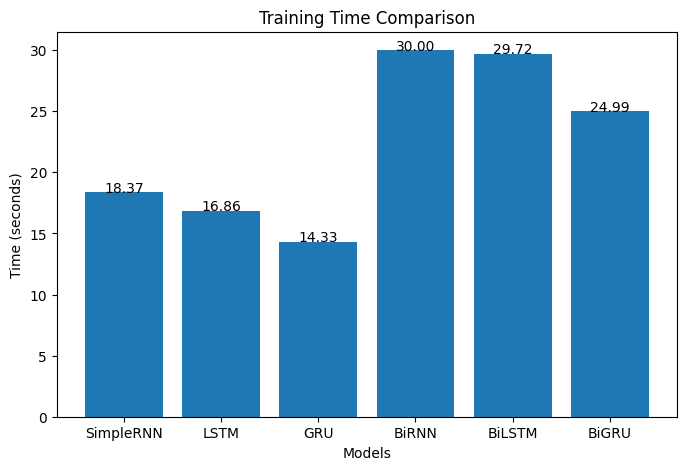

In [ ]:
import matplotlib.pyplot as plt

models = ['SimpleRNN', 'LSTM', 'GRU', 'BiRNN', 'BiLSTM', 'BiGRU']
times = [rnn_time, lstm_time, gru_time, birnn_time, bilstm_time, bigru_time]

plt.figure(figsize=(8,5))
plt.bar(models, times)

plt.title('Training Time Comparison')
plt.xlabel('Models')
plt.ylabel('Time (seconds)')

for i, v in enumerate(times):
    plt.text(i, v, f'{v:.2f}', ha='center')

plt.show()